# <em> PCA, KNN, and Data Modeling $\newline$ with MNIST</em>


***

### Imports

In [1]:
import numpy as np
from scipy.integrate import quad
import sklearn as sk
from sklearn import datasets, linear_model
from sklearn.preprocessing import PolynomialFeatures
#For plotting
import matplotlib.pyplot as plt

from matplotlib import cm
import matplotlib
from matplotlib import rcParams
from matplotlib.pyplot import figure
from matplotlib import rc
import pylab
import os

from matplotlib.patches import Ellipse
import matplotlib as mpl
from numpy.linalg import eigvals

pgf_with_latex = {
        'text.usetex': False,
        'pgf.rcfonts': False,
        "pgf.preamble": [
                r"\usepackage{siunitx}"
                ]
}


%matplotlib widget


universal_linewidth=2
universal_fontsize=25

***

#### PCA MNIST

In another notebook, we used the UMAP module to reduce the MNIST dataset to 2 dimensions (from 784) for easy visualization and observed that different classes (10 digits - "0", "1", ..., "9") got separated nicely into clusters when the MNIST data are embedded into lower dimensions by UMAP.

Instead of the UMAP module, here we use the PCA method for dimensionality reduction.

PCA is a technique for reducing the number of dimensions in a dataset whilst retaining most information. It is using the correlation between some dimensions and tries to provide a minimum number of variables that keeps the maximum amount of variation or information about how the original data is distributed. It uses the eigenvalues and eigenvectors of the data-matrix. These eigenvectors of the covariance matrix have the property that they point along the major directions of variation in the data. These are the directions of maximum variation in a dataset. Here, we use the scikit-learn implementation of PCA: https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html


In [2]:
from sklearn.datasets import fetch_openml

# load the MNIST data
mnist = fetch_openml('mnist_784')
X = mnist.data
Y = mnist.target

X = X.to_numpy()
Y = Y.to_numpy()

"$X$" contains information about the given MNIST digits. We have a 28x28 pixel grid, so each image is a vector of length 784; we have 70,000 images (digits), so $X$ is a 70,000x784 matrix. "$Y$" is a label (0-9; the category to which each image belongs) vector of length 70,000.

<span style="color:blue"> <i> Do the following:

1.  Randomly shuffle data (i.e. randomize the order)

  (Note: The label $Y_1$ corresponds to a vector $X_{1j}$, and even after shuffling, $Y_1$ should still correspond to $X_{1j}$.)
  
  
2.  Select 1/3 of the data. (You are free to work with a larger set of the data, but it will take much longer time to train.)


3.  Split data into training and test samples using train_test_split (https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html). Set train_size = 0.8. (80% of $X$ is our training samples.) Print the dimension of training and test samples. </i></span> <br>

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.utils import check_random_state


# shuffle data
def unison_shuffled_copies(a, b):
    assert len(a) == len(b)
    p = np.random.permutation(len(a))
    return a[p], b[p]

X,Y = unison_shuffled_copies(X, Y)

# pick training and test data sets
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,train_size=0.8)

print('training size:', np.shape(X_train), np.shape(Y_train) ) 
print('testing size:', np.shape(X_test), np.shape(Y_test) )

training size: (56000, 784) (56000,)
testing size: (14000, 784) (14000,)


Many machine learning algorithms are also not scale invariant, and hence we need to scale the data (different features to a uniform scale). All this comes under preprocessing the data. (http://scikit-learn.org/stable/modules/preprocessing.html#preprocessing) PCA is a prime example of when such normalization is important; if the variables are not measured on the same scale, then each principal component can be dominated by a single variable.

Here, the MNIST pixel values in images should also be scaled prior to providing the images as an input to PCA. There are three main types of pixel scaling techniques: normalization (scaling pixel to the range 0-1), centering (scale pixel values to have a zero-mean), and standardization (scale pixel values to have a zero-mean and unit-variance).

First, let us try normalization. Each pixel contains a greyscale value quantified by an integer between 0 and 255. To standardize the dataset, we normalize the "$X$" data in the interval [0, 1].

<span style="color:blue"> <i> Normalize the X data (both training and test).

In [4]:
X_train, X_test =(X_train/255., X_test/255.)

Next, using scikit-learn's PCA module, we can select the first two principal components from the original 784 dimensions.

In [5]:
from sklearn.decomposition import PCA

1. Define the PCA model with the first 2 principal components:

&nbsp; &nbsp; &nbsp; &nbsp; **pca = PCA(n_components=2)**

2. Using "fit_transform," fit the model with the training X data and apply the dimensionality reduction on it.

&nbsp; &nbsp; &nbsp;&nbsp; **X_train_PCA = pca.fit_transform(training X data)**

3. With the same model, apply the dimensionality reduction on the test X data.

&nbsp; &nbsp; &nbsp; &nbsp; **X_test_PCA = pca.transform(test X data)**

<span style="color:blue"> <i> 3. For both training and test samples, create a scatterplot of the first and second principal component and color each of the different types of digits with a different color. Label each axis (e.g. x-axis: 1st principal component, y-axis: 2nd principal component). How does it compare to the UMAP results?

In [6]:
pca = PCA(n_components=2)
X_train_PCA = pca.fit_transform(X_train)
X_test_PCA = pca.transform(X_test)

In [7]:
classes = [ '0',
            '1',
            '2',
            '3',
            '4',
            '5',
            '6',
            '7',
            '8',
            '9']

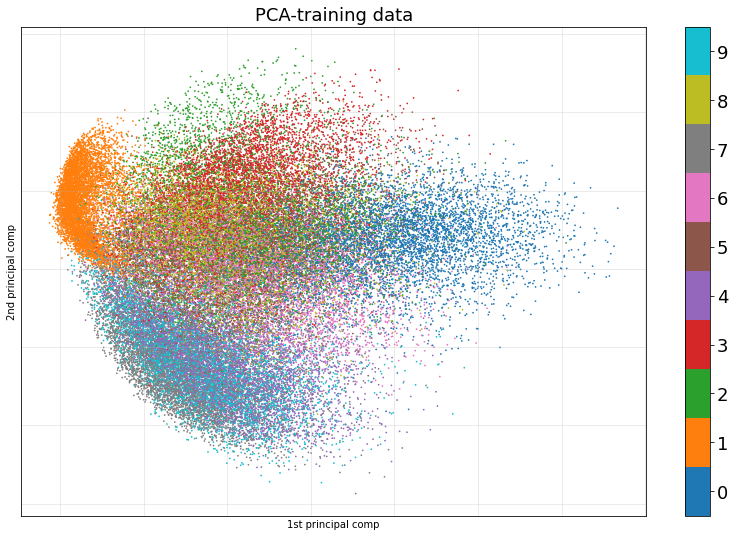

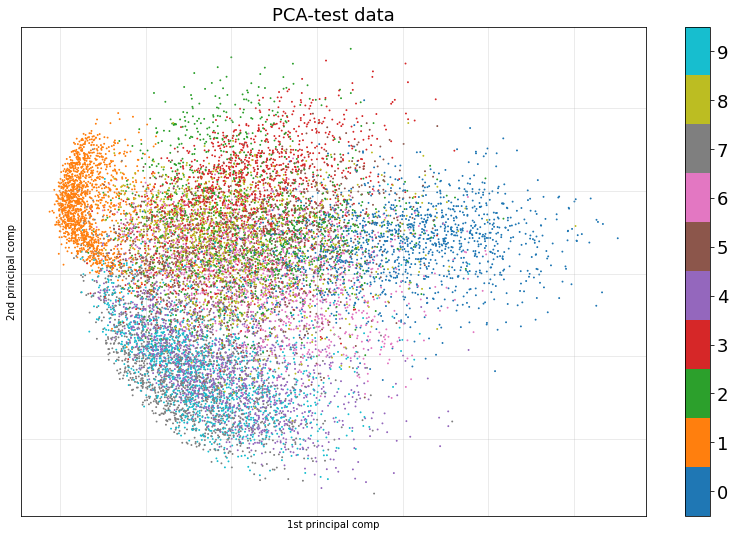

In [55]:
# Make Plot
fig, ax = plt.subplots(figsize=(14, 9)) 
color = Y_train.astype(int) 
plt.scatter(X_train_PCA[:, 0], X_train_PCA[:, 1],
            c=color, cmap='tab10', s=0.5)

plt.title("PCA-training data", fontsize=18) 
plt.xlabel("1st principal comp") 
plt.ylabel("2nd principal comp")

cbar = plt.colorbar(boundaries=np.arange(11)-0.5) 
cbar.set_ticks(np.arange(10)) 
cbar.ax.tick_params(labelsize=18) 
cbar.set_ticklabels(classes)

ax.grid(alpha=0.3, which='both')

ax.tick_params(
    axis='both',
    which='both',
    bottom=False, top=False,
    left=False, right=False,
    labelbottom=False, labelleft=False
)

plt.show()

fig, ax = plt.subplots(figsize=(14, 9)) 
color = Y_test.astype(int)
plt.scatter(X_test_PCA[:, 0], X_test_PCA[:, 1], 
            c=color, cmap="tab10", s=0.8)
 
plt.title("PCA-test data", fontsize=18) 
plt.xlabel("1st principal comp") 
plt.ylabel("2nd principal comp")
ax.grid(alpha=0.3, which='both')
cbar = plt.colorbar(boundaries=np.arange(11)-0.5) 
cbar.set_ticks(np.arange(10)) 
cbar.ax.tick_params(labelsize=18) 
cbar.set_ticklabels(classes)

ax.tick_params(
    axis='both',
    which='both',
    bottom=False, top=False,
    left=False, right=False,
    labelbottom=False, labelleft=False
)

<span style="color:blue"> <i> Select the first three principal components and make 3D scatterplot on the training data. 

In [8]:
from mpl_toolkits.mplot3d import Axes3D

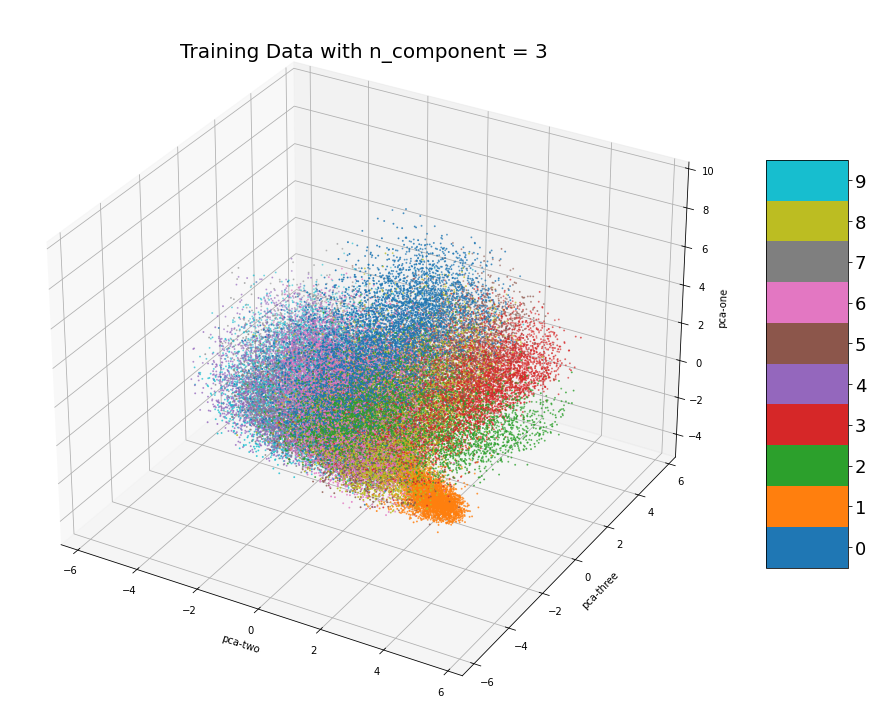

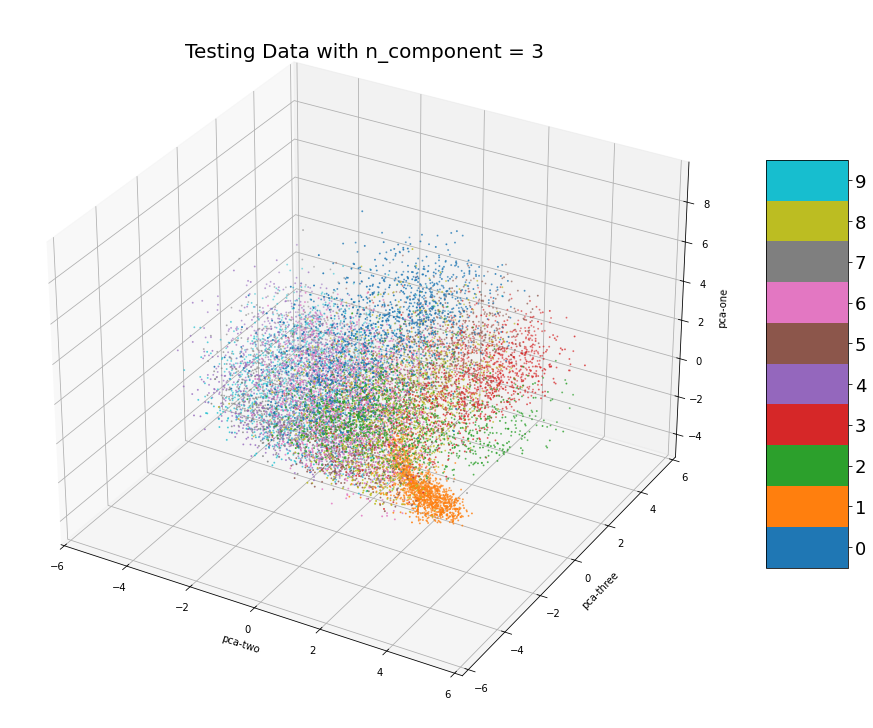

In [76]:
pca = PCA(n_components=3)
X_train_PCA = pca.fit_transform(X_train) 
X_test_PCA = pca.transform(X_test)

# Plot Train Set
fig = plt.figure(figsize=(16,15))
ax = fig.add_subplot(projection='3d') 
sctt = ax.scatter(X_train_PCA[:, 1], 
                  X_train_PCA[:, 2], 
                  X_train_PCA[:, 0], 
                  c = Y_train.astype(int),
                  cmap='tab10', 
                  s=0.9)

plt.title('Training Data with n_component = 3', y=1, fontsize=20)
ax.set_xlabel('pca-two') 
ax.set_ylabel('pca-three') 
ax.set_zlabel('pca-one')

cbar = fig.colorbar(sctt, ax = ax, shrink = .5, aspect = 5, boundaries=np.arange(11)-0.5) 
cbar.set_ticks(np.arange(10)) 
cbar.ax.tick_params(labelsize=18) 
cbar.set_ticklabels(classes)

plt.show()


# Plot Test set 
fig = plt.figure(figsize=(16,15))
ax = fig.add_subplot(projection='3d') 
sctt = ax.scatter(X_test_PCA[:, 1], 
                  X_test_PCA[:, 2], 
                  X_test_PCA[:, 0], 
                  c = Y_test.astype(int),
                  cmap='tab10', 
                  s=0.9)

plt.title('Testing Data with n_component = 3', y=1, fontsize=20)
ax.set_xlabel('pca-two') 
ax.set_ylabel('pca-three') 
ax.set_zlabel('pca-one') 

cbar = fig.colorbar(sctt, ax = ax, shrink = .5, aspect = 5, boundaries=np.arange(11)-0.5) 
cbar.set_ticks(np.arange(10)) 
cbar.ax.tick_params(labelsize=18) 
cbar.set_ticklabels(classes)



plt.show()

From the graph we can see the two or three components definitely hold some information, especially for specific digits, but clearly not enough to set all of them apart. There are other techniques, such as UMAP module or t-SNE (t-Distributed Stochastic Neighbouring Entities), which can better reduce the dimensions for visualisation.

***

In [9]:
from sklearn.neighbors import KNeighborsClassifier as knn

Now, we will introduce K-nearest neighbors (KNN), one of the most widely used machine learning classification techniques. We use scikit-learn implementation of KNN: https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html

Ideally, we should tune KNN hyperparameters by doing a grid search using k-fold cross validation, but in this exercise we simply use default parameters with n_neighbors = 6.

1.  Define the knn classifier

&nbsp; **clf = knn(n_neighbors=6)**

2.  Fit the model

&nbsp; **clf.fit(training X data, training Y/target data)**

3.  Get the classification accuracy on the test data

&nbsp; **clf.score(test X data, test Y/target data)**

<span style="color:blue"> <i> Evaluate the classification accuracy on the test data using a KNN classifier.

In [10]:
clf = knn(n_neighbors=6)
clf.fit(X_train, Y_train)
acc_784_feat = clf.score(X_test, Y_test)
acc_784_feat

0.97

The above KNN classifier considers all 784 features for each image when making its decisions. What if you do not need that many? It is possible that a lot of those features do not really affect our predictions that much. Or worse, KNN could be considering feature anomalies that are unique to our training data, resulting in overfitting. One way to deal with this is by removing features that aren’t contributing much.

Now, suppose you take the first two principal components from PCA and fit your model using those two components.

&nbsp; **pca = PCA(n_components=2)**

&nbsp; **X_train_PCA = pca.fit_transform(training X data)**

&nbsp; **X_test_PCA = pca.transform(test X data)**

Now you can take X_train_PCA, along with training Y data, to fit the KNN model and evaluate the classification accuracy.

<span style="color:blue"> <i> Evaluate the classification accuracy with different number of PCA componenets. Let N_PCA_component = [2, 10, 20, 30, 40, 50, 60, 100, 200, 300, 400, 700]. Plot classification accuracy vs. number of PCA components. How does it compare to the accuracy in Part 5? Draw a horizontal line for the accuracy with all 784 features.

In [11]:
N_PCA_component = [2, 10, 20, 30, 40, 50, 60, 100, 200, 300, 400, 700, 784]
clf_N_scores = []

for N in N_PCA_component:
    pca = PCA(n_components=N)
    X_train_PCA = pca.fit_transform(X_train)
    X_test_PCA = pca.transform(X_test)

    clf = knn(n_neighbors=6)
    clf.fit(X_train_PCA, Y_train)
    clf_N_scores.append(clf.score(X_test_PCA, Y_test))


In [12]:
acc_784_feat, clf_N_scores[-1]

(0.9719285714285715, 0.9719285714285715)

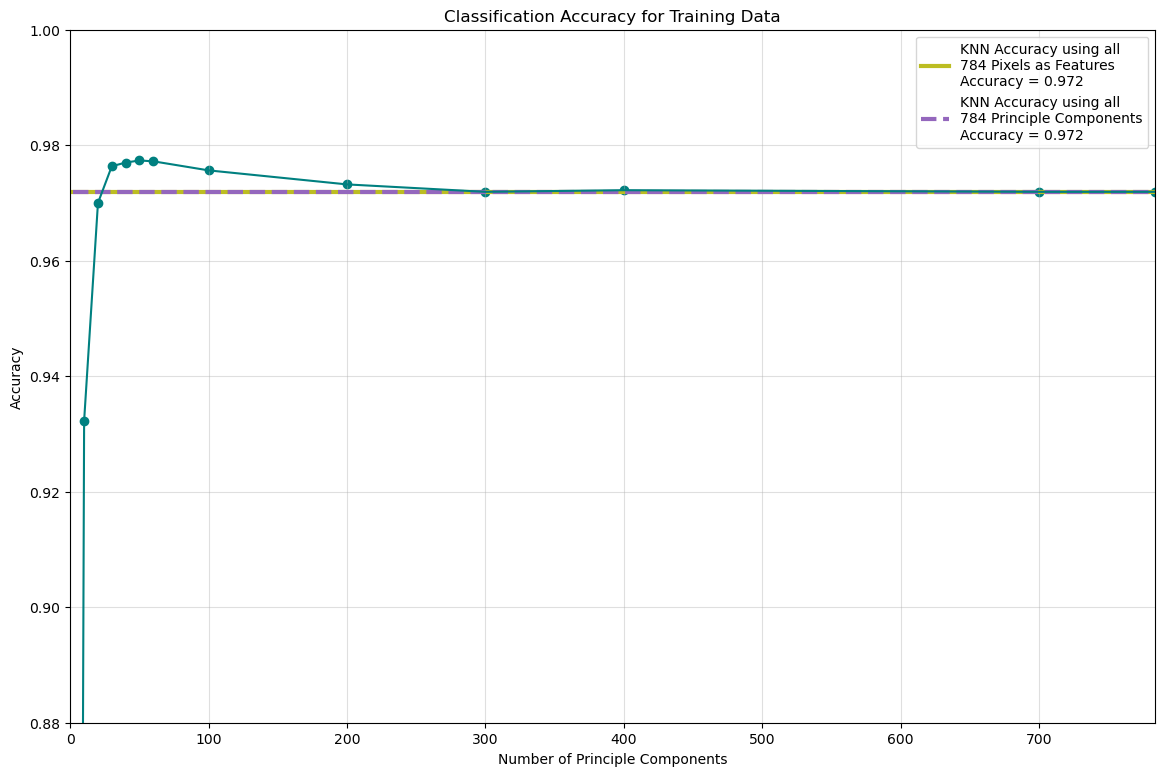

In [30]:
fig = plt.figure(figsize = (14, 9))
plt.title('Classification Accuracy for Training Data')

# line of KNN without PCA
plt.plot(N_PCA_component, np.ones(len(N_PCA_component))*acc_784_feat, linewidth=3, color='tab:olive',
         label=f'KNN Accuracy using all \n784 Pixels as Features\nAccuracy = {np.round(acc_784_feat,3)}')
# line of KNN wit 784 PCA components
plt.plot(N_PCA_component, np.ones(len(N_PCA_component))*clf_N_scores[-1], '--', linewidth=3, color='tab:purple',
         label=f'KNN Accuracy using all \n784 Principle Components\nAccuracy = {np.round(clf_N_scores[-1],3)}')

plt.scatter(N_PCA_component, clf_N_scores, color='teal')
plt.plot(N_PCA_component, clf_N_scores, 'teal')

plt.ylim(0.88,1)
plt.xlim(0,784)
plt.legend()
plt.xlabel('Number of Principle Components')
plt.ylabel('Accuracy')
plt.grid(alpha=0.4)

<span style="color:blue"> <i> Instead of the PCA method, fit the UMAP model with the training data and do unsupervised learning. Reduce data to 2 dimensions (embed to 2 dimensions) and train the KNN model on the embedded training data. Compared to before, does it give you a higher classification accuracy even with n_component = 2?

In [12]:
import umap

In [13]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
import plotly.io as pio
pio.renderers.default = "notebook_connected"

In [35]:
model = umap.UMAP(n_components=2)
embedding_train = model.fit_transform(X_train, Y_train)
embedding_test = model.transform(X_test)

clf = knn(n_neighbors=6)
clf.fit(embedding_train, Y_train)
acc_umap2comp = clf.score(embedding_test, Y_test)

In [36]:
print('Accuracies:\n\n',
      f'KNN+PCA with the first two principal components: {clf_N_scores[0]}\n',
      f'UMAP with the first two principal components: {acc_umap2comp}')

Accuracies:

 KNN+PCA with the first two principal components: 0.4164285714285714
 UMAP with the first two principal components: 0.7755714285714286


UMAP with n=2 gives a significantly higher accuracy than KNN with n=2 but not higher than KNN with an optimal number of principle components

***

Instead of pixel normalization, we can also try feature rescaling through standardization (rescaling the features such that they have the properties of a standard normal distribution with a mean of zero and a standard deviation of one). We can use sklearn.preprocessing.StandardScaler for this job.


In [21]:
from sklearn.preprocessing import StandardScaler

1. Define the StandardScaler

&nbsp; &nbsp; &nbsp; **sc = StandardScaler()**

2. Fit the training X data and then transform it.

&nbsp; &nbsp; &nbsp; **X_train = sc.fit_transform(training X data)**

3. Perform standardization on the test X data.

&nbsp; &nbsp; &nbsp; **X_test = sc.transform(test X data)**

<span style="color:blue"> <i> Re-load the MNIST data (Repeat previous work) and try standardization on both training and test X data following the above steps. Evaluate the classification accuracy using a KNN classifier. How does it compare?

In [22]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

mnist = fetch_openml('mnist_784')
X = mnist.data
Y = mnist.target

X = X.to_numpy()
Y = Y.to_numpy()

# shuffle data
def unison_shuffled_copies(a, b):
    assert len(a) == len(b)
    p = np.random.permutation(len(a))
    return a[p], b[p]

X,Y = unison_shuffled_copies(X, Y)
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, train_size = 0.8)

print('training set size:', np.shape(X_train), np.shape(Y_train) )
print('testing set size:', np.shape(X_test), np.shape(Y_test) )

training set size: (56000, 784) (56000,)
testing set size: (14000, 784) (14000,)


In [23]:
# Standardize
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

clf = knn(n_neighbors=6)
clf.fit(X_train, Y_train)
acc_784_feat = clf.score(X_test, Y_test)

print('Standardized KNN Classification Accuracy: ', acc_784_feat)

Standardized KNN Classification Accuracy:  0.9452142857142857


<span style="color:blue"> <i> Again, take the previous data (standardized X data) and do unsupervised learning using the UMAP module. Reduce the data to 2 dimensions, and plot the embedding as a scatterplot (for the training data) and color by the target array. How does it compare to our previous plots? Which pixel rescaling method do you think works better?

In [43]:
# fit model with standardized data
model = umap.UMAP(n_components=2)
embedding_train_unsupervised = model.fit_transform(X_train)
embedding_test_unsupervised = model.transform(X_test)

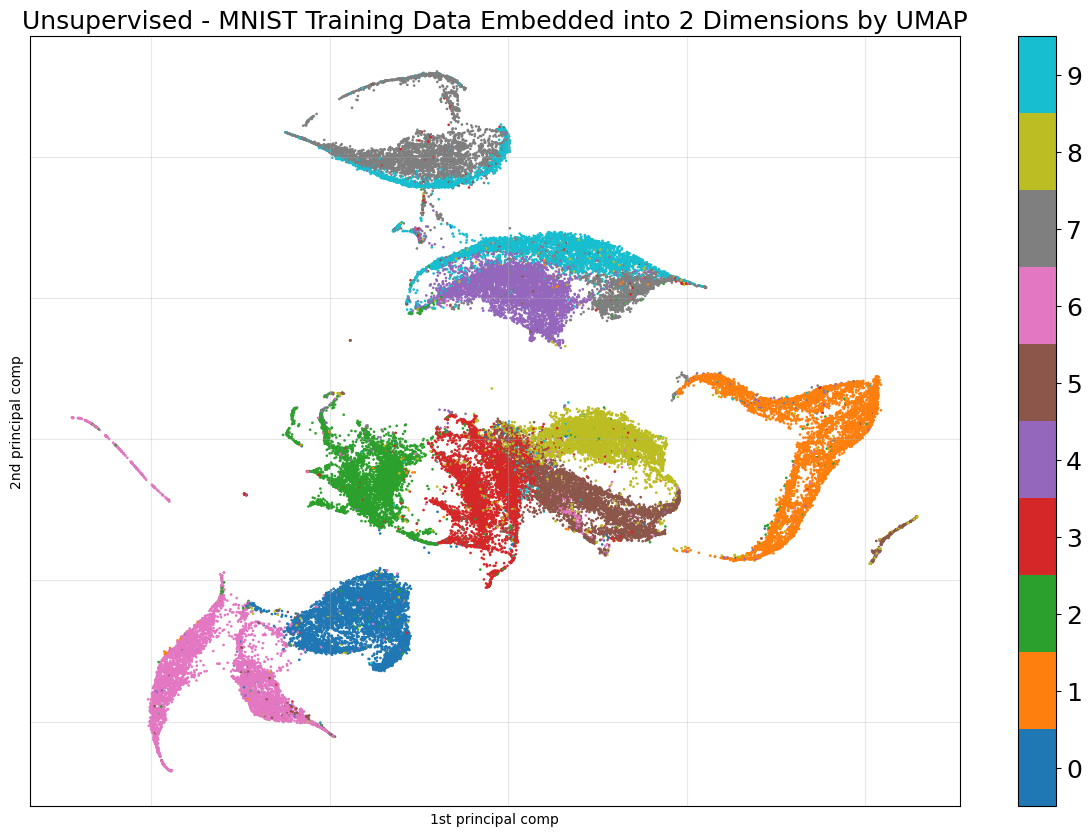

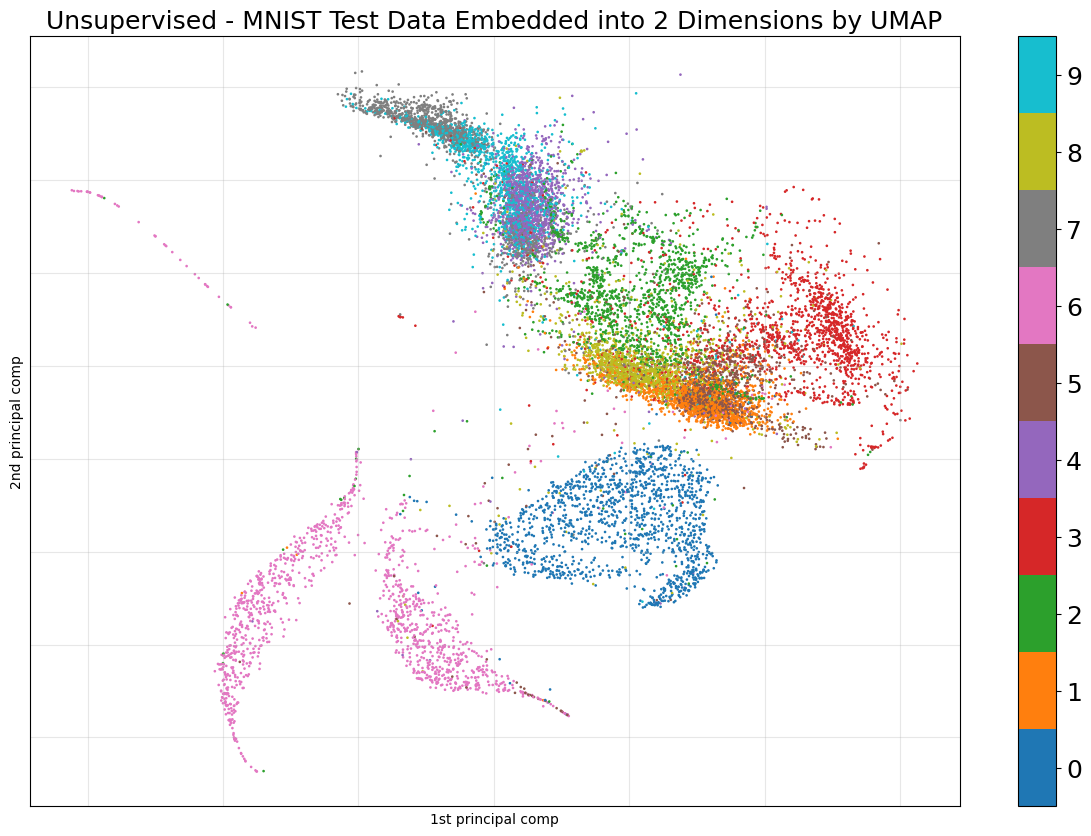

In [54]:
# Make Plots

# Train Set
fig, ax = plt.subplots(figsize=(15, 10)) 
color = Y_train.astype(int) 
plt.scatter(embedding_train_unsupervised[:, 0], 
            embedding_train_unsupervised[:, 1],
            c=color, cmap='tab10', s=0.8)

plt.title("Unsupervised - MNIST Training Data Embedded into 2 Dimensions by UMAP", fontsize=18) 
plt.xlabel("1st principal comp") 
plt.ylabel("2nd principal comp")

cbar = plt.colorbar(boundaries=np.arange(11)-0.5) 
cbar.set_ticks(np.arange(10)) 
cbar.ax.tick_params(labelsize=18) 
cbar.set_ticklabels(classes)

ax.grid(alpha=0.3, which='both')

ax.tick_params(
    axis='both',
    which='both',
    bottom=False, top=False,
    left=False, right=False,
    labelbottom=False, labelleft=False
)

plt.show()

# Test Set
fig, ax = plt.subplots(figsize=(15, 10)) 
color = Y_test.astype(int) 
plt.scatter(embedding_test_unsupervised[:, 0], 
            embedding_test_unsupervised[:, 1],
            c=color, cmap='tab10', s=0.8)

plt.title("Unsupervised - MNIST Test Data Embedded into 2 Dimensions by UMAP", fontsize=18) 
plt.xlabel("1st principal comp") 
plt.ylabel("2nd principal comp")

cbar = plt.colorbar(boundaries=np.arange(11)-0.5) 
cbar.set_ticks(np.arange(10)) 
cbar.ax.tick_params(labelsize=18) 
cbar.set_ticklabels(classes)

ax.grid(alpha=0.3, which='both')

ax.tick_params(
    axis='both',
    which='both',
    bottom=False, top=False,
    left=False, right=False,
    labelbottom=False, labelleft=False
)



In [24]:
# fit model with standardized data into 3 dim
model = umap.UMAP(n_components=3)
embedding_train_unsupervised = model.fit_transform(X_train)
embedding_test_unsupervised = model.transform(X_test)

In [25]:
import plotly.express as px
import pandas as pd
import plotly.graph_objects as go

In [26]:
# Build a DataFrame
df = pd.DataFrame({
    "x": embedding_train_unsupervised[:, 0],
    "y": embedding_train_unsupervised[:, 1],
    "z": embedding_train_unsupervised[:, 2],
    "label": Y_train.astype(int)
})

df["label_str"] = df["label"].astype(str)


fig = go.Figure()

for i in range(10):
    mask = df["label"] == i

    fig.add_trace(go.Scatter3d(
        x=df.loc[mask, "x"],
        y=df.loc[mask, "y"],
        z=df.loc[mask, "z"],
        mode='markers',
        showlegend=False,
        marker=dict(size=2, color=px.colors.qualitative.Plotly[i]),
        name=str(i)
    ))
    
fig.update_layout(
    title="Unsupervised - MNIST Training Data UMAP Embedding in 3D",
    width=940,
    height=800
)
    
for i in range(10): 
    fig.add_trace(go.Scatter3d( x=[None], y=[None], z=[None], 
                               mode='markers', 
                               marker=dict(size=12, color=px.colors.qualitative.Plotly[i]), 
                               name=str(i) )) 

fig.show()

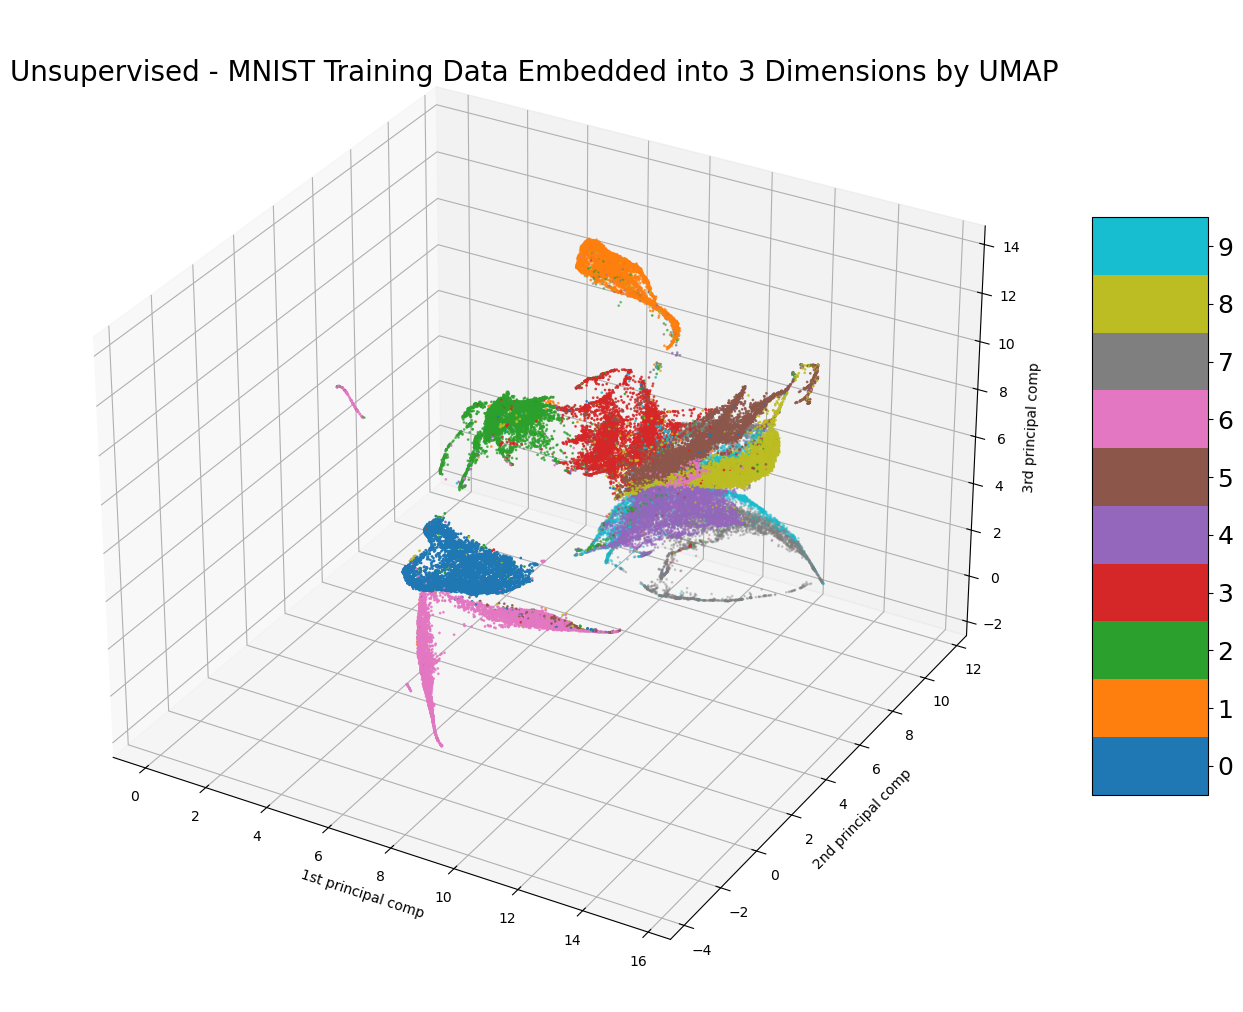

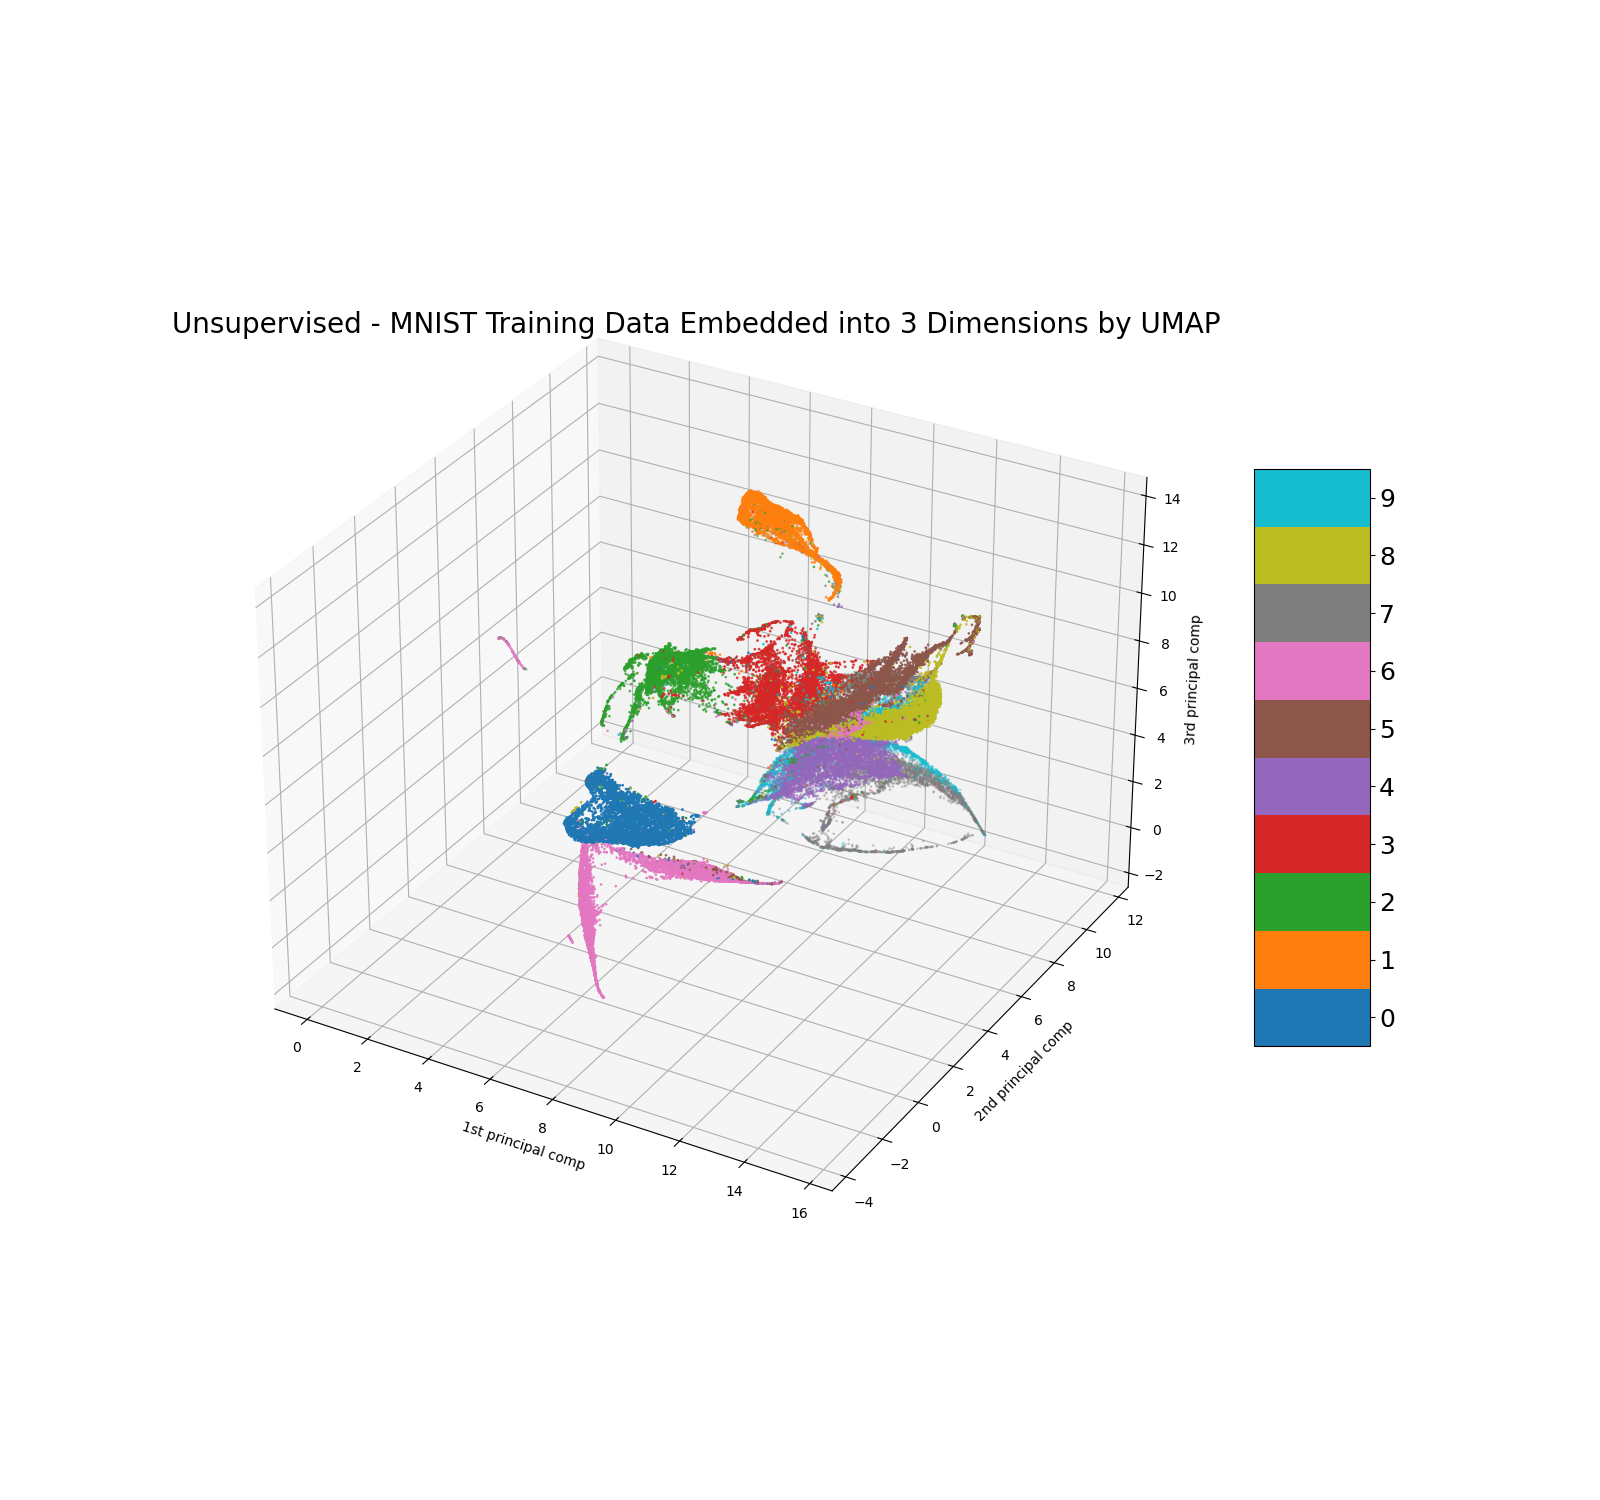

In [16]:
# Plot Train Set

fig = plt.figure(figsize=(16,15))
ax = fig.add_subplot(projection='3d') 
sctt = ax.scatter(embedding_train_unsupervised[:, 0], 
                  embedding_train_unsupervised[:, 1], 
                  embedding_train_unsupervised[:, 2], 
                  c = Y_train.astype(int),
                  cmap='tab10', 
                  s=0.9)

plt.title("Unsupervised - MNIST Training Data Embedded into 3 Dimensions by UMAP", y=1, fontsize=20)
ax.set_xlabel("1st principal comp") 
ax.set_ylabel("2nd principal comp") 
ax.set_zlabel("3rd principal comp")

cbar = fig.colorbar(sctt, ax = ax, shrink = .5, aspect = 5, boundaries=np.arange(11)-0.5) 
cbar.set_ticks(np.arange(10)) 
cbar.ax.tick_params(labelsize=18) 
cbar.set_ticklabels(classes)
display(fig)

In [27]:
# Build a DataFrame
df = pd.DataFrame({
    "x": embedding_test_unsupervised[:, 0],
    "y": embedding_test_unsupervised[:, 1],
    "z": embedding_test_unsupervised[:, 2],
    "label": Y_test.astype(int)
})

df["label_str"] = df["label"].astype(str)


fig = go.Figure()


for i in range(10):
    mask = df["label"] == i

    fig.add_trace(go.Scatter3d(
        x=df.loc[mask, "x"],
        y=df.loc[mask, "y"],
        z=df.loc[mask, "z"],
        mode='markers',
        showlegend=False,
        marker=dict(size=2, color=px.colors.qualitative.Plotly[i]),
        name=str(i)
    ))
    
fig.update_layout(
    title="Unsupervised - MNIST Test Data UMAP Embedding in 3D",
    width=940,
    height=800
)
    
for i in range(10): 
    fig.add_trace(go.Scatter3d( x=[None], y=[None], z=[None], 
                               mode='markers', 
                               marker=dict(size=12, color=px.colors.qualitative.Plotly[i]), 
                               name=str(i) )) 

fig.show()

***